# 6.1 Классификация.Соискатели

1. Скачайте этот ноутбук к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Отправьте результат нам

### Полезная литература

- [ODS - классификация](https://habrahabr.ru/company/ods/blog/322534/)
- [Коллаборативная фильтрация - рекомендательная система](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D0%BB%D0%BB%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%B8%D0%B2%D0%BD%D0%B0%D1%8F_%D1%84%D0%B8%D0%BB%D1%8C%D1%82%D1%80%D0%B0%D1%86%D0%B8%D1%8F)
- [Метрики расстояний - косинусная, минковского, проклятье размерности ](http://www.machinelearning.ru/wiki/images/9/9a/Sem1_knn.pdf)
- [Offtop: метрики качества рекомендательных систем](https://habrahabr.ru/company/dca/blog/281066/)

## kNN - ближайшие соседи (15 баллов)

Рассмотрим задачу из соревнования [Amazon Employee Access Challenge](https://www.kaggle.com/c/amazon-employee-access-challenge).

В данной задаче предлагается предсказать, будет ли одобрен запрос сотрудника на получение доступа к тому или иному ресурсу. Все признаки являются категориальными.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import scale

In [2]:
!gdown --id 1jaFR-icouBkD24TjNt75o6bBEiDXaORG

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1jaFR-icouBkD24TjNt75o6bBEiDXaORG
To: /content/train.csv
100% 2.04M/2.04M [00:00<00:00, 88.8MB/s]


In [3]:
df = pd.read_csv('train.csv')
df.head()
# ACTION - это целевой признак

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


Обратим внимание, что выборка не сбалансированная. В качестве метрики качества будем использовать [f1-score](https://en.wikipedia.org/wiki/F1_score).
$$F_1 = 2 \cdot \frac{\mathrm{precision} \cdot \mathrm{recall}}{\mathrm{precision} + \mathrm{recall}}$$

$$precision = \frac{TP}{TP+FP}$$

$$recall = \frac{TP}{TP+FN}$$

0.9421099209618847


<Axes: xlabel='ACTION', ylabel='count'>

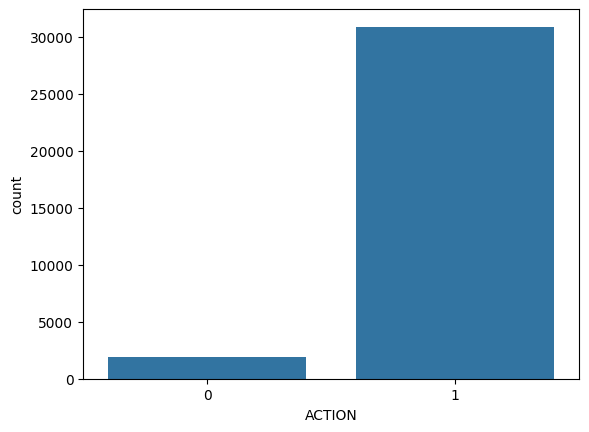

In [8]:
print(df['ACTION'].mean())
sns.countplot(x='ACTION', data=df)

In [9]:
# число значений у признаков
for col_name in df.columns:
    print(col_name, len(df[col_name].unique()))

ACTION 2
RESOURCE 7518
MGR_ID 4243
ROLE_ROLLUP_1 128
ROLE_ROLLUP_2 177
ROLE_DEPTNAME 449
ROLE_TITLE 343
ROLE_FAMILY_DESC 2358
ROLE_FAMILY 67
ROLE_CODE 343


In [10]:
X = df.drop(['ACTION'], axis=1)
y = df['ACTION']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.8)

# Baseline (4 балла)

Сразу проверим как ведет себя kNN на неподготовленных данных и без тюнинга. Зафиксируйте `n_neighbors=5`, `p=2`.

- создайте экземпляр `KNeighborsClassifier` с указанными параметрами, обучите его методом `fit` и предскажите значения `predict` для треничровчных данных `X_test`.
- постройте отчет классификации (classification_report)
- постройте confusion matrix и нарисуйте heatmap

Обратите внимание на confusion matrix. Какой вывод вы можете сделать из неё? Вспомните лекцию и значение ошибок 1 и 2 рода.

In [11]:
knn_baseline = KNeighborsClassifier(n_neighbors=5, p=2)
knn_baseline.fit(X_train, y_train)
y_pred = knn_baseline.predict(X_test)

При фиксированном `n_neighbors=10` проверьте значение метрики на кроссвалидации на 5-фолдах для разных значений `p` из `(1,2,4,6)`. При каком значение `p` метрика достигает максимума?

При кроссвалидации у вас будет получаться N разных значений метрики. Выводите среднее значение и стандартное отклонение.

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.22      0.03      0.05      1534
           1       0.94      0.99      0.97     24682

    accuracy                           0.94     26216
   macro avg       0.58      0.51      0.51     26216
weighted avg       0.90      0.94      0.91     26216



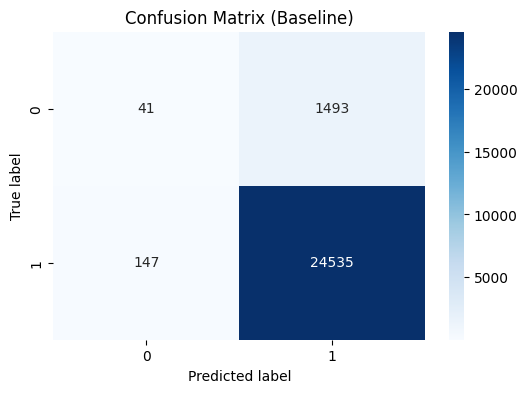

In [17]:
# 2. Отчет классификации
print("Classification Report (Baseline):")
print(classification_report(y_test, y_pred))

# 3. Confusion matrix и heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Baseline)')
plt.show()

# Счетчики (6 баллов)

Очевидно, что предсказывать лейбл объекта, используя при этом метрический алгоритм на категориальных признаках - это ОЧЕНЬ странная затея. Не удивительно что качество ужасное. Необходимо каким-то образом заменить категориальные признаки вещественными:

- OneHotEncoding - это когда для каждого признака создают другие N бинарных признаков, где N - это количество категорий у категориального признака.
- Счетчики - об это написано в статье http://blogs.technet.com/b/machinelearning/archive/2015/02/17/big-learning-made-easy-with-counts.aspx.

Мы реализуем алгоритм Счетчиков. Его нет в sklearn, поэтому придется реализовать самому.

Для каждого категориального признака создайте 3 других признака:
1. Число `counts` объектов в обучающей выборке с таким же значением признака.
2. Число `successes` объектов первого класса ($y = 1$) в обучающей выборке с таким же значением признака.
3. Сглаженное отношение двух предыдущих величин: (`successes` + 1) / (`counts` + 2).

Поскольку признаки, содержащие информацию о целевой переменной, могут привести к переобучению, может оказаться полезным сделать *фолдинг*: разбить обучающую выборку на $n$ частей, и для $i$-й части считать `counts` и `successes` по всем остальным частям. Для тестовой выборки используются счетчики, посчитанные по всей обучающей выборке. Реализуйте и такой вариант. Можно использовать $n = 3$.

Обучение надо проводить только по новым признакам. Изначальные мы не используем.

Счетчики нужно считать по `train`, а в `test` использовать эти же счетчики, иначе счетчики будут содержать информацию о всем датасете что приведет к переобучение!

Подсказка - вам нужно для каждой колонки посчитать 2 аггрегации - сумму и количество. Для замены конкретного значения посчитанным используйте функцию apply над датафреймом. Простое решение займет около 10 строк кода.

![](http://images6.fanpop.com/image/photos/38600000/taiga-iamyourenemy-38620719-282-160.gif)

In [20]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

data = pd.DataFrame(index=df.index)

data = pd.DataFrame(index=X_train.index)
data_test = pd.DataFrame(index=X_test.index)

for col in X_train.columns:
    data[f'{col}_counts'] = 0.0
    data[f'{col}_successes'] = 0.0
    data[f'{col}_ratio'] = 0.0

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]


        counts_dict = X_tr.groupby(col).size().to_dict()
        successes_dict = y_tr.groupby(X_tr[col]).sum().to_dict()


        def get_counters(val):
            c = counts_dict.get(val, 0)
            s = successes_dict.get(val, 0)
            r = (s + 1) / (c + 2)
            return pd.Series([c, s, r])


        data.loc[X_val.index, [f'{col}_counts', f'{col}_successes', f'{col}_ratio']] = X_val[col].apply(get_counters).values


    full_counts = X_train.groupby(col).size().to_dict()
    full_successes = y_train.groupby(X_train[col]).sum().to_dict()

    def get_full_counters(val):
        c = full_counts.get(val, 0)
        s = full_successes.get(val, 0)
        r = (s + 1) / (c + 2)
        return pd.Series([c, s, r])

    data_test[[f'{col}_counts', f'{col}_successes', f'{col}_ratio']] = X_test[col].apply(get_full_counters).values

Проверьте какое качество теперь получается на кроссвалидации для новых данных.

Classification Report (Счетчики):
              precision    recall  f1-score   support

           0       0.09      0.02      0.04      1534
           1       0.94      0.98      0.96     24682

    accuracy                           0.93     26216
   macro avg       0.52      0.50      0.50     26216
weighted avg       0.89      0.93      0.91     26216



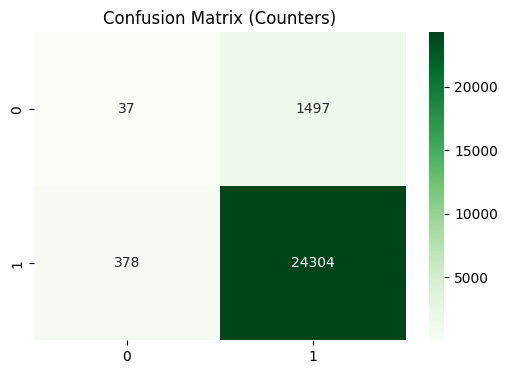

In [24]:
X_train_counts = data
X_test_counts = data_test

knn_counts = KNeighborsClassifier(n_neighbors=5, p=2)
knn_counts.fit(X_train_counts, y_train)
y_pred_counts = knn_counts.predict(X_test_counts)

print("Classification Report (Счетчики):")
print(classification_report(y_test, y_pred_counts))

cm_counts = confusion_matrix(y_test, y_pred_counts)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_counts, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Counters)')
plt.show()

- постройте отчет классификации (classification_report)
- постройте confusion matrix и нарисуйте heatmap

Оцените на сколько улучшилось качество.

# Co-co-co-combo (5 баллов)

Добавьте в исходную выборку парные признаки — то есть для каждой пары $(f_i, f_j)$, $i < j$ исходных категориальных признаков добавьте новый категориальный признак $f_{ij}$, значение которого является конкатенацией значений $f_i$ и $f_j$ (желательно через какой-нибудь специальный символ во избежание коллизий). Посчитайте счетчики для этой выборки, найдите качество метода $k$ ближайших соседей с наилучшим $k$ (с фолдингом и без).

In [26]:
from itertools import combinations

df_combo = df.copy()

features = [col for col in df.columns if col != 'ACTION']

for col1, col2 in combinations(features, 2):
    new_col_name = f"{col1}_{col2}"
    df_combo[new_col_name] = df_combo[col1].astype(str) + '_' + df_combo[col2].astype(str)

In [27]:
data_combo = pd.DataFrame(index=df_combo.index)

kf = KFold(n_splits=3, shuffle=True, random_state=42)


train_idx_global = X_train.index
test_idx_global = X_test.index

for col_name in df_combo.columns:
    if col_name == 'ACTION':
        continue
    data_combo[f'{col_name}_counts'] = 0.0
    data_combo[f'{col_name}_successes'] = 0.0
    data_combo[f'{col_name}_ratio'] = 0.0


    df_train_part = df_combo.loc[train_idx_global]
    y_train_part = df.loc[train_idx_global, 'ACTION']

    for tr_idx, val_idx in kf.split(df_train_part):

        real_tr_idx = df_train_part.iloc[tr_idx].index
        real_val_idx = df_train_part.iloc[val_idx].index

        X_tr = df_train_part.loc[real_tr_idx]
        y_tr = y_train_part.loc[real_tr_idx]
        X_val = df_train_part.loc[real_val_idx]


        counts_dict = X_tr.groupby(col_name).size().to_dict()
        successes_dict = y_tr.groupby(X_tr[col_name]).sum().to_dict()

        def get_counters(val):
            c = counts_dict.get(val, 0)
            s = successes_dict.get(val, 0)
            r = (s + 1) / (c + 2) # Сглаживание
            return pd.Series([c, s, r])


        data_combo.loc[real_val_idx, [f'{col_name}_counts', f'{col_name}_successes', f'{col_name}_ratio']] = X_val[col_name].apply(get_counters).values


    full_counts = df_train_part.groupby(col_name).size().to_dict()
    full_successes = y_train_part.groupby(df_train_part[col_name]).sum().to_dict()

    def get_full_counters(val):
        c = full_counts.get(val, 0)
        s = full_successes.get(val, 0)
        r = (s + 1) / (c + 2)
        return pd.Series([c, s, r])

    X_test_part = df_combo.loc[test_idx_global]
    data_combo.loc[test_idx_global, [f'{col_name}_counts', f'{col_name}_successes', f'{col_name}_ratio']] = X_test_part[col_name].apply(get_full_counters).values

/tmp/ipykernel_423/3317506313.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_combo[f'{col_name}_successes'] = 0.0
/tmp/ipykernel_423/3317506313.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_combo[f'{col_name}_ratio'] = 0.0
/tmp/ipykernel_423/3317506313.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use 

Classification Report (Combo features):
              precision    recall  f1-score   support

           0       0.11      0.04      0.06      1534
           1       0.94      0.98      0.96     24682

    accuracy                           0.92     26216
   macro avg       0.53      0.51      0.51     26216
weighted avg       0.89      0.92      0.91     26216



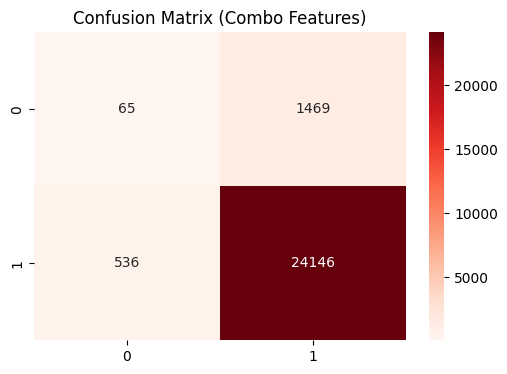

In [28]:
# Разбиваем обратно
X_train_combo_final = data_combo.loc[train_idx_global]
X_test_combo_final = data_combo.loc[test_idx_global]

# Обучаем kNN
knn_combo = KNeighborsClassifier(n_neighbors=5, p=2) # Здесь можно подставить лучший k, найденный ранее
knn_combo.fit(X_train_combo_final, y_train)
y_pred_combo = knn_combo.predict(X_test_combo_final)

# Отчет
print("Classification Report (Combo features):")
print(classification_report(y_test, y_pred_combo))

# Матрица ошибок
cm_combo = confusion_matrix(y_test, y_pred_combo)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_combo, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix (Combo Features)')
plt.show()

- постройте отчет классификации (classification_report)
- постройте confusion matrix и нарисуйте heatmap

Оцените на сколько улучшилось качество. Не похоже ли это на переобусение?

Внимание! Обучение на этом этапе может быть долгим. На i5 16GB кроссвалидация на 5 фолдах заняла 30 минут!

# Target encoding
Допустим, у нас есть категоральный признак х и целевой у; нужно сгруппировать значения признака х по значениям признака у и посчитать среднее. Затем все значения из х заменяем на среднее по соответствующему у.


Подробнее написано в статье: https://maxhalford.github.io/blog/target-encoding/


In [30]:
df_target = df.copy()

In [31]:
data_target = pd.DataFrame(index=df_target.index)

global_mean = y_train.mean()

for col_name in df_target.columns:
    if col_name == 'ACTION':
        continue
    target_mean = y_train.groupby(X_train[col_name]).mean()


    data_target[col_name] = df_target[col_name].map(target_mean).fillna(global_mean)

Classification Report (Target Encoding):
              precision    recall  f1-score   support

           0       0.29      0.15      0.20      1534
           1       0.95      0.98      0.96     24682

    accuracy                           0.93     26216
   macro avg       0.62      0.57      0.58     26216
weighted avg       0.91      0.93      0.92     26216



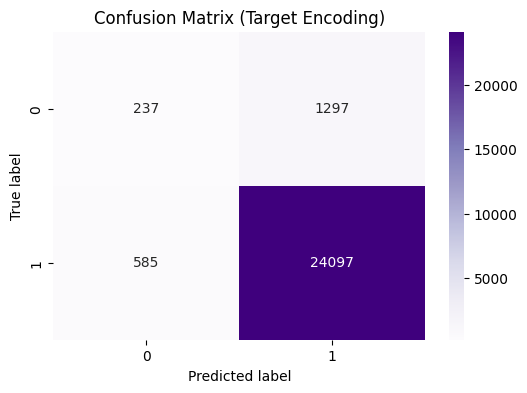

In [32]:

X_train_te = data_target.loc[X_train.index]
X_test_te = data_target.loc[X_test.index]


knn_te = KNeighborsClassifier(n_neighbors=5, p=2)
knn_te.fit(X_train_te, y_train)
y_pred_te = knn_te.predict(X_test_te)

# отчет
print("Classification Report (Target Encoding):")
print(classification_report(y_test, y_pred_te))

# матрица ошибок
cm_te = confusion_matrix(y_test, y_pred_te)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_te, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix (Target Encoding)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

Сравните результаты.

Какой недостаток есть у target encoding?



Переобучение из-за утечки данных, ошибки на редких категориях в обучающей выборке запоминаются, и часто будут ошибочные предсказания